In [1]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread

import skimage
from skimage.morphology import disk
from skimage.morphology import remove_small_holes

import scipy
from scipy.ndimage import binary_dilation
from scipy.ndimage import distance_transform_edt

import matplotlib.pyplot as plt
import matplotlib

from tqdm import tqdm

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [118]:
# Import images and csv files

tracks_dir = '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250509_vascular/D10/Unperturbed/50ms/Tracking/Run20250611/Factor4Link5'
tracks_path = os.path.join(tracks_dir,'*.csv')
tracks_files = np.sort(glob.glob(tracks_path))

# Extract the integers before the first underscore in the filenames
loaded_image_ids = {
    os.path.basename(f).split('_')[0]  # Extract the part before the first underscore
    for f in tracks_files
}
cytoplasm_dir = '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250509_vascular/D10/Unperturbed/ROIs/Cytoplasm'
cytoplasm_path = os.path.join(cytoplasm_dir, '**', '*.tif')  # Use '**' to match subdirectories
cytoplasm_files = np.sort(glob.glob(cytoplasm_path, recursive=True))

# Filter the new images based on matching IDs
cytoplasm_files = np.array([
    f for f in cytoplasm_files
    if os.path.basename(f).split('_')[0] in loaded_image_ids
])

nucleus_dir = '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250509_vascular/D10/Unperturbed/ROIs/Nucleus'
nucleus_path = os.path.join(nucleus_dir,'*.tif')
nucleus_files = np.sort(glob.glob(nucleus_path))

# Filter the new images based on matching IDs
nucleus_files = np.array([
    f for f in nucleus_files
    if os.path.basename(f).split('_')[0] in loaded_image_ids
])

In [119]:
print(len(tracks_files))
print(len(cytoplasm_files))
print(len(nucleus_files))

7
7
7


In [120]:
# Read images and csv files into lists

cytoplasm_images = []

for file in tqdm(cytoplasm_files):
    image = imread(file)
    cytoplasm_images.append(image)

nucleus_images = []

for file in tqdm(nucleus_files):
    image = imread(file)
    nucleus_images.append(image)

tracks = []

for file in tqdm(tracks_files):
    tracks_all = pd.read_csv(file)
    tracks.append(tracks_all)

for i in range(len(tracks)):
    tracks[i] = tracks[i].loc[:, ~tracks[i].columns.str.contains('^Unnamed')]

tracks[0].head()

100%|██████████| 7/7 [00:17<00:00,  2.57s/it]


,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_raw_intensity,mean_actin_intensity,mean_tubulin_intensity,particle,track_id,unique_id
0,0,1,391.133797,168.464841,5012.273281,4722.500000,1.294516,1.206063,8076.00,951.50,6413.75,2,1.0_2.0,1244
1,0,1,456.512321,168.859783,5228.028450,3318.000000,1.186488,0.372031,7719.75,1378.00,2767.25,3,1.0_3.0,320
2,0,1,436.798012,170.930202,4130.865352,4269.000000,1.413696,1.309231,8091.75,650.00,6481.25,4,1.0_4.0,1258
3,0,1,412.297110,171.414800,3405.175361,4211.335443,1.506792,1.256611,6342.75,570.00,5570.25,5,1.0_5.0,218
4,0,1,440.857537,180.455547,4333.790654,4555.219367,1.360535,1.440795,8107.75,673.75,3101.50,8,1.0_8.0,412


#### Calculate distance to nucleus

In [121]:
# Compute distance transform

pixel_size = 0.134  # Pixel size in micrometers
default_distance = 150  # Default distance in micrometers for ROIs without a nucleus

for csv, nucleus in zip(tracks, nucleus_images):
    csv['distance_nucleus'] = np.nan  # Create an empty column

    for roi in csv['roi_id'].unique():
        tracks_roi = csv[csv['roi_id'] == roi]
        
        # Check if the nucleus exists for the current ROI
        if roi not in np.unique(nucleus):
            # Assign the default distance for all coordinates in this ROI
            csv.loc[csv['roi_id'] == roi, 'distance_nucleus'] = default_distance
            continue
        
        # Compute the distance transform for the nucleus mask
        mask_distance_transform = scipy.ndimage.distance_transform_edt(~(nucleus == roi))
        
        # Round and clip coordinates
        coords_round = np.round(np.array(tracks_roi[['x', 'y']])).astype(int)
        coords_round[:, 0] = np.clip(coords_round[:, 0], 0, mask_distance_transform.shape[0] - 1)
        coords_round[:, 1] = np.clip(coords_round[:, 1], 0, mask_distance_transform.shape[1] - 1)
        
        # Calculate distances in micrometers
        distances_in_um = mask_distance_transform[coords_round[:, 1], coords_round[:, 0]] * pixel_size
        csv.loc[csv['roi_id'] == roi, 'distance_nucleus'] = distances_in_um


In [122]:
largest_values = tracks[-1].nlargest(20, 'distance_nucleus')
largest_values

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_raw_intensity,mean_actin_intensity,mean_tubulin_intensity,particle,track_id,unique_id,distance_nucleus
27176,93,1,312.566957,874.828402,3.538080e+03,3457.000000,1.775726,1.525910,7343.25,868.50,2405.75,2348,1.0_2348.0,485,34.743231
27231,94,1,313.911292,875.378298,4.276706e+03,4126.601397,1.028060,1.101660,7035.00,870.50,2126.25,2348,1.0_2348.0,485,34.710139
28277,97,1,313.041905,872.525901,4.252631e+03,3669.000000,1.124073,1.221367,6515.25,781.75,2428.25,2348,1.0_2348.0,485,34.482811
27819,96,1,314.715429,873.172615,4.148013e+03,3657.000000,1.038002,1.211362,7144.75,880.50,2312.75,2348,1.0_2348.0,485,34.417399
28775,99,1,311.609399,870.790430,4.123196e+03,4568.568400,1.090053,1.047035,7910.00,1100.50,2513.25,2348,1.0_2348.0,485,34.254762
10811,37,1,679.588075,468.693111,1.230207e-08,5653.858364,2.619780,1.594883,5658.50,579.50,1775.00,983,1.0_983.0,615,30.147618
10998,38,1,679.680947,469.072071,9.222577e+02,6134.684717,2.108891,1.303398,6130.75,579.50,1775.00,983,1.0_983.0,615,30.147618
10102,35,1,679.736885,475.012194,5.501287e+02,5398.561421,1.947987,1.492718,5411.50,602.25,1869.50,390,1.0_390.0,220,30.083224
11019,38,1,679.592274,475.277754,1.357679e+03,5484.822770,1.360731,1.190378,4789.75,602.25,1869.50,390,1.0_390.0,220,30.083224
11539,39,1,679.510935,474.981148,8.324041e+02,4878.745670,1.550831,1.385076,5119.50,602.25,1869.50,390,1.0_390.0,220,30.083224


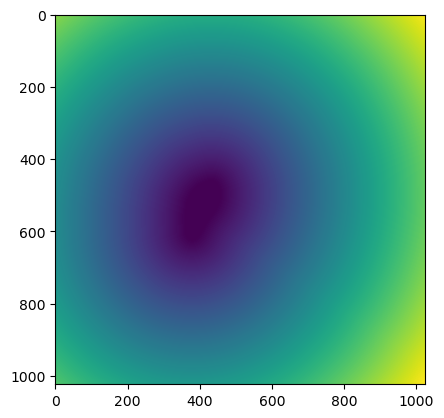

In [123]:
plt.imshow(mask_distance_transform)

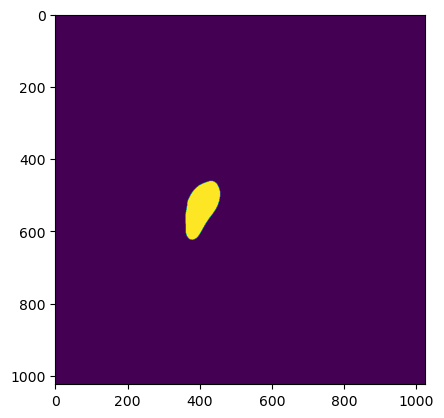

In [124]:
plt.imshow(nucleus_images[-1]==roi)

#### Merging cytoplasm mask with nucleus

In [125]:
# Adding nuclei back to cytplasm mask

whole_cells = []

for cyto_mask, nucleus_mask in zip(cytoplasm_images, nucleus_images):

    # Define maximum expansion in pixels
    max_expansion = 70  # Maximum expansion distance in pixels

    # Ensure masks have the same shape
    assert cyto_mask.shape == nucleus_mask.shape, "Masks must have the same dimensions"

    # Get unique nucleus labels
    nucleus_labels = np.unique(nucleus_mask)
    nucleus_labels = nucleus_labels[nucleus_labels > 0]  # Remove background (0)

    # Create a new expanded nucleus mask
    expanded_nucleus_mask = np.copy(nucleus_mask)

    for label_value in nucleus_labels:
        # Extract nucleus region
        nucleus_region = (nucleus_mask == label_value)
        
        # Extract corresponding cytoplasm region
        cyto_region = (cyto_mask == label_value)

        # Initialize dilation step
        dilation_step = 1
        expanded_region = nucleus_region.copy()  # Start with the original nucleus region
        
        while dilation_step <= max_expansion:
            # Apply dilation with a small disk (disk(1) to expand step by step)
            expanded_region = binary_dilation(expanded_region, disk(1))  # Expand by 1 pixel per step
            
            # Check if **all** of the expanded region touches the cytoplasm
            if np.all(expanded_region & cyto_region):  # Stop if ALL of the expanded region touches cytoplasm
                print(f"Expansion stopped at {dilation_step} pixels due to touching cytoplasm.")
                break  # Stop expanding when all of it touches the cytoplasm
            
            dilation_step += 1  # Increment the dilation step
        
        # Assign the expanded region to the output mask
        expanded_nucleus_mask[expanded_region] = label_value  # Update the expanded region in the mask

    # Merge the expanded nuclei with the cytoplasm mask
    whole_cell = np.where(expanded_nucleus_mask > 0, expanded_nucleus_mask, cyto_mask)
    whole_cells.append(whole_cell)

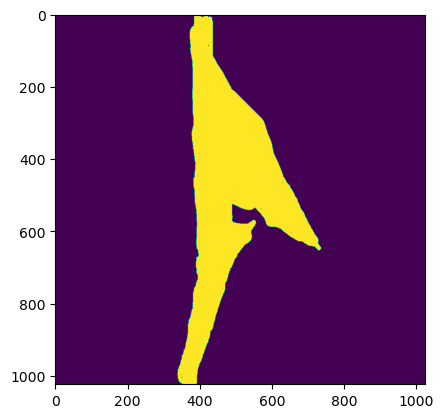

In [126]:
plt.imshow(whole_cells[0])

In [127]:
# Removes small holes in the masks

def fill_small_holes_per_label(label_img, area_threshold=64):
    # Create an output array to store the result
    filled = np.zeros_like(label_img)
    
    # Process each unique label (excluding 0, the background)
    for region_label in np.unique(label_img):
        if region_label == 0:
            continue
        mask = label_img == region_label
        filled_mask = remove_small_holes(mask, area_threshold=area_threshold)
        filled[filled_mask] = region_label

    return filled

# Apply to all images in the list
whole_cells_filled = [fill_small_holes_per_label(img, area_threshold=364) for img in whole_cells]


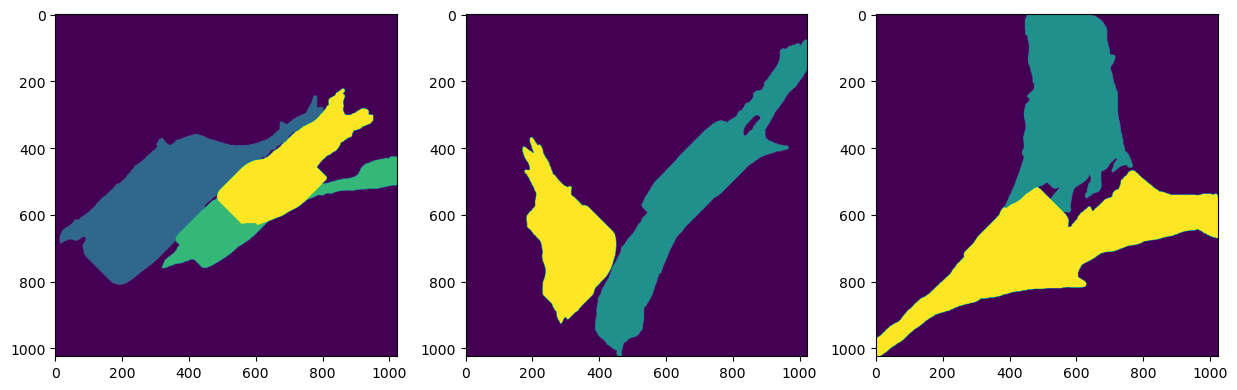

In [128]:
fig, ax = plt.subplots(1,3, figsize = (15, 8))
ax[0].imshow(whole_cells_filled[3])
ax[1].imshow(whole_cells_filled[4])
ax[2].imshow(whole_cells_filled[5])

#### Calculate distance to edge

In [129]:
# Calculates distance of each spot to the nearest edge of the mask

def compute_distance_to_edge(label_img, df):
    roi_ids = df['roi_id'].unique()
    distance_maps = {}

    for roi_id in roi_ids:
        mask = label_img == roi_id
        if np.any(mask):
            distance_map = distance_transform_edt(mask)
            distance_maps[roi_id] = distance_map
        else:
            distance_maps[roi_id] = np.zeros_like(label_img, dtype=float)

    distances = []
    for i in range(len(df)):
        row = df.iloc[i]
        x, y, roi_id = int(row['x']), int(row['y']), row['roi_id']
        if roi_id in distance_maps:
            distance_map = distance_maps[roi_id]
            x = np.clip(x, 0, distance_map.shape[1] - 1)
            y = np.clip(y, 0, distance_map.shape[0] - 1)
            distances.append(distance_map[y, x] * 0.134)  # convert pixels to µm
        else:
            distances.append(np.nan)

    df = df.copy()
    df['distance_edge'] = distances
    return df

# Apply with tqdm to track progress

tracks_with_distances = [
    compute_distance_to_edge(label_img, df)
    for label_img, df in tqdm(zip(whole_cells_filled, tracks), total=len(tracks), desc="Computing distances")
]

Computing distances: 100%|██████████| 7/7 [00:31<00:00,  4.44s/it]


In [130]:
tracks_with_distances[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_raw_intensity,mean_actin_intensity,mean_tubulin_intensity,particle,track_id,unique_id,distance_nucleus,distance_edge
0,0,1,391.133797,168.464841,5012.273281,4722.500000,1.294516,1.206063,8076.00,951.50,6413.75,2,1.0_2.0,1244,17.841636,1.474000
1,0,1,456.512321,168.859783,5228.028450,3318.000000,1.186488,0.372031,7719.75,1378.00,2767.25,3,1.0_3.0,320,14.586317,1.498166
2,0,1,436.798012,170.930202,4130.865352,4269.000000,1.413696,1.309231,8091.75,650.00,6481.25,4,1.0_4.0,1258,14.890891,3.906738
3,0,1,412.297110,171.414800,3405.175361,4211.335443,1.506792,1.256611,6342.75,570.00,5570.25,5,1.0_5.0,218,16.120707,4.288000
4,0,1,440.857537,180.455547,4333.790654,4555.219367,1.360535,1.440795,8107.75,673.75,3101.50,8,1.0_8.0,412,13.586305,4.136674


In [131]:
# Creates distance maps for all ROIs in an image

def compute_combined_distance_map(label_img, pixel_size_um=0.134):
    distance_map_combined = np.zeros_like(label_img, dtype=float)

    for roi_id in np.unique(label_img):
        if roi_id == 0:
            continue  # skip background
        mask = label_img == roi_id
        if np.any(mask):
            dist_map = distance_transform_edt(mask)
            distance_map_combined[mask] = dist_map[mask] * pixel_size_um  # convert to µm

    return distance_map_combined

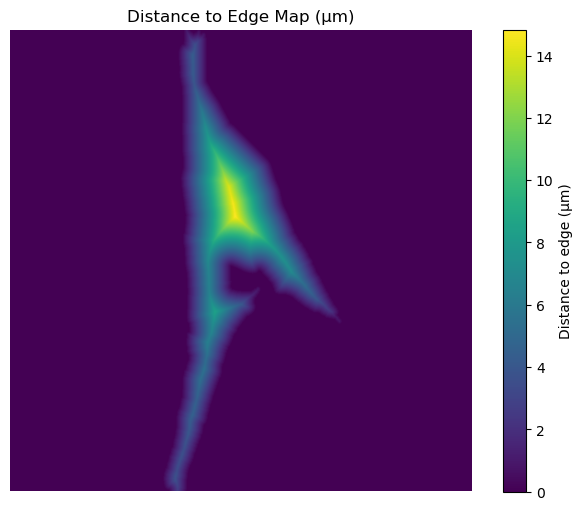

In [132]:
# Display distance transforms

label_img = whole_cells_filled[0]
dist_map_um = compute_combined_distance_map(label_img)

plt.figure(figsize=(8, 6))
plt.imshow(dist_map_um, cmap='viridis')
plt.colorbar(label='Distance to edge (µm)')
plt.title("Distance to Edge Map (µm)")
plt.axis('off')
plt.show()

In [133]:
# Saving updated csv files

# Base directory and subfolder
base_dir = os.path.dirname(tracks_dir)  # Get the directory of the current file
subfolder = "Dist-nuc_dist-edge"

subfolder_path = os.path.join(base_dir, subfolder)
os.makedirs(subfolder_path, exist_ok=True)  # Create folder if it doesn't exist

for table, file_path in zip(tracks_with_distances, tracks_files):

    # Define the output file path with the correct filename
    output_file = os.path.join(subfolder_path, os.path.basename(file_path))

    # Save the modified CSV
    table.to_csv(output_file, index=False)

print(f"Tables saved in: {subfolder_path}")

Tables saved in: /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250509_vascular/D10/Unperturbed/50ms/Tracking/Run20250611/Dist-nuc_dist-edge
